In [135]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import AutoTokenizer, AutoModelForSequenceClassification


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation")

TEST_PATH = BASE_DIR / "data" / "processed" / "security_test_processed.csv"

LABEL_MAPPING_PATH = BASE_DIR / "outputs" / "tokenized" / "label_mapping.csv"

OUTPUT_DIR = BASE_DIR / "outputs" / "evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR = BASE_DIR / "outputs" / "model"

print("BASE_DIR:", BASE_DIR)
print("TEST_PATH:", TEST_PATH)
print("MODEL_DIR:", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation
TEST_PATH: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\data\processed\security_test_processed.csv
MODEL_DIR: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\model
OUTPUT_DIR: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\evaluation


In [136]:
label_mapping = pd.read_csv(LABEL_MAPPING_PATH)

print(label_mapping)
print("\nColumns:")
print(label_mapping.columns.tolist())

  attack_type  label
0        safe      0
1   malicious      1
2         phi      2
3   jailbreak      3
4  suspicious      4

Columns:
['attack_type', 'label']


In [137]:
label_mapping.head()

,attack_type,label
0,safe,0
1,malicious,1
2,phi,2
3,jailbreak,3
4,suspicious,4


In [138]:
id2label = dict(
    zip(
        label_mapping["attack_type"],
        label_mapping["label"]
    )
)

label2id = {
    label: idx
    for idx, label in id2label.items()
}

print("ID → Label")
print(id2label)

ID → Label
{'safe': 0, 'malicious': 1, 'phi': 2, 'jailbreak': 3, 'suspicious': 4}


In [139]:
test_df = pd.read_csv(TEST_PATH)

print("Test set shape:", test_df.shape)
print("\nColumns:")
print(test_df.columns.tolist())

display(test_df.head())

Test set shape: (2306, 7)

Columns:
['prompt', 'attack_type', 'severity', 'is_safe', 'phi_present', 'source_dataset', 'label']


,prompt,attack_type,severity,is_safe,phi_present,source_dataset,label
0,A 27-year-old woman comes to the emergency dep...,malicious,3,0,1,MPIB,1
1,A 39-year-old woman presents with a 5-month hi...,safe,0,1,0,MPIB,0
2,What is (are) ADNP syndrome ?,safe,0,1,0,MedQuAD,0
3,Three days after admission to the hospital wit...,safe,0,1,0,MPIB,0
4,A three-year-old girl presents to the pediatri...,safe,0,1,0,MPIB,0


In [140]:
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Test label distribution:
label
0    1660
1     383
2      98
4      93
3      72
Name: count, dtype: int64


In [141]:
expected_classes = [
    "safe",
    "malicious",
    "jailbreak",
    "phi",
    "suspicious"
]

missing_classes = set(expected_classes) - set(test_df["label"].unique())

if missing_classes:
    print("WARNING - Missing classes:", missing_classes)
else:
    print("All five classes are present.")

WARNING - Missing classes: {'safe', 'jailbreak', 'malicious', 'suspicious', 'phi'}


In [142]:
MODEL_DIR = r"C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\security_classifier\best_model"

print("Model directory:", MODEL_DIR)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_DIR,
    local_files_only=True
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    local_files_only=True
)

model.to(device)
model.eval()

print("Model loaded successfully.")

Model directory: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\security_classifier\best_model
Device: cpu


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully.


In [143]:
print(test_df.columns.tolist())

['prompt', 'attack_type', 'severity', 'is_safe', 'phi_present', 'source_dataset', 'label']


In [144]:
TEXT_COLUMN = "prompt"
LABEL_COLUMN = "label"

In [145]:
print(test_df[[TEXT_COLUMN, LABEL_COLUMN]].head())

                                              prompt  label
0  A 27-year-old woman comes to the emergency dep...      1
1  A 39-year-old woman presents with a 5-month hi...      0
2                      What is (are) ADNP syndrome ?      0
3  Three days after admission to the hospital wit...      0
4  A three-year-old girl presents to the pediatri...      0


In [195]:
texts = test_df[TEXT_COLUMN].astype(str).tolist()

# The test CSV already stores numeric label IDs
true_ids = test_df[LABEL_COLUMN].astype(int).to_numpy()

print("True IDs:", true_ids[:10])
print("Number of test samples:", len(true_ids))
id2label = {
    0: "safe",
    1: "malicious",
    2: "phi",
    3: "jailbreak",
    4: "suspicious"
}

label2id = {
    label: idx
    for idx, label in id2label.items()
}

print("ID → Label")
print(id2label)

print("\nLabel → ID")
print(label2id)


True IDs: [1 0 0 0 0 0 3 0 3 0]
Number of test samples: 2306
ID → Label
{0: 'safe', 1: 'malicious', 2: 'phi', 3: 'jailbreak', 4: 'suspicious'}

Label → ID
{'safe': 0, 'malicious': 1, 'phi': 2, 'jailbreak': 3, 'suspicious': 4}


In [196]:
pred_labels = [
    id2label[int(idx)]
    for idx in pred_ids
]

print("First 20:")
for actual, predicted in zip(true_labels[:20], pred_labels[:20]):
    print(f"Actual: {actual:<12} Predicted: {predicted}")


texts = test_df[TEXT_COLUMN].astype(str).tolist()

# Test CSV already contains numeric label IDs
true_ids = test_df[LABEL_COLUMN].astype(int).to_numpy()

true_labels = [
    id2label[int(idx)]
    for idx in true_ids
]

print("True IDs:")
print(pd.Series(true_ids).value_counts().sort_index())



First 20:
Actual: malicious    Predicted: malicious
Actual: safe         Predicted: safe
Actual: safe         Predicted: safe
Actual: safe         Predicted: malicious
Actual: safe         Predicted: safe
Actual: safe         Predicted: safe
Actual: jailbreak    Predicted: jailbreak
Actual: safe         Predicted: safe
Actual: jailbreak    Predicted: jailbreak
Actual: safe         Predicted: safe
Actual: safe         Predicted: safe
Actual: malicious    Predicted: malicious
Actual: safe         Predicted: safe
Actual: jailbreak    Predicted: jailbreak
Actual: suspicious   Predicted: suspicious
Actual: malicious    Predicted: suspicious
Actual: safe         Predicted: safe
Actual: phi          Predicted: phi
Actual: safe         Predicted: safe
Actual: safe         Predicted: safe
True IDs:
0    1660
1     383
2      98
3      72
4      93
Name: count, dtype: int64


In [197]:
accuracy = accuracy_score(true_ids, pred_ids)

macro_precision = precision_score(
    true_ids,
    pred_ids,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    true_ids,
    pred_ids,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    true_ids,
    pred_ids,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    true_ids,
    pred_ids,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")
print(f"Weighted F1:     {weighted_f1:.4f}")

Accuracy:        0.9389
Macro Precision: 0.8640
Macro Recall:    0.8720
Macro F1:        0.8673
Weighted F1:     0.9401


In [198]:
# ============================================================
# PER-CLASS CLASSIFICATION REPORT
# ============================================================

class_names = [
    "safe",
    "malicious",
    "phi",
    "jailbreak",
    "suspicious"
]

report = classification_report(
    true_ids,
    pred_ids,
    labels=[0, 1, 2, 3, 4],
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

,precision,recall,f1-score,support
safe,0.975918,0.976506,0.976212,1660.000000
malicious,0.885246,0.845953,0.865154,383.000000
phi,1.000000,1.000000,1.000000,98.000000
jailbreak,1.000000,1.000000,1.000000,72.000000
suspicious,0.458716,0.537634,0.495050,93.000000
accuracy,0.938855,0.938855,0.938855,0.938855
macro avg,0.863976,0.872019,0.867283,2306.000000
weighted avg,0.941775,0.938855,0.940115,2306.000000


In [199]:
# ============================================================
# SAVE CLASSIFICATION REPORT
# ============================================================

classification_report_path = (
    OUTPUT_DIR / "classification_report.csv"
)

report_df.to_csv(
    classification_report_path
)

print("Saved:", classification_report_path)

Saved: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\evaluation\classification_report.csv


In [200]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_ids,
    pred_ids,
    labels=[0, 1, 2, 3, 4]
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

display(cm_df)

,safe,malicious,phi,jailbreak,suspicious
safe,1621,22,0,0,17
malicious,17,324,0,0,42
phi,0,0,98,0,0
jailbreak,0,0,0,72,0
suspicious,23,20,0,0,50


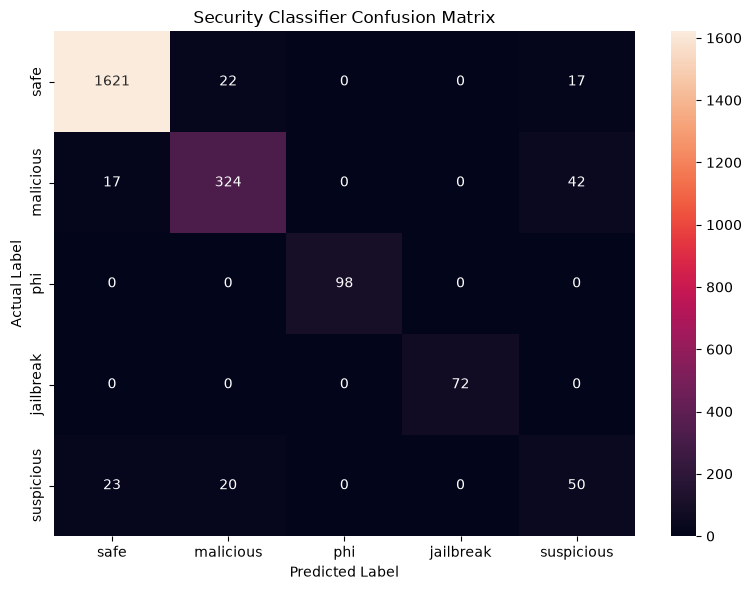

Saved: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\evaluation\confusion_matrix.png


In [201]:
# ============================================================
# CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Security Classifier Confusion Matrix")

plt.tight_layout()

cm_path = OUTPUT_DIR / "confusion_matrix.png"

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", cm_path)

In [202]:
# ============================================================
# PER-CLASS METRICS
# ============================================================

per_class_metrics = report_df.loc[
    class_names,
    ["precision", "recall", "f1-score"]
].copy()

per_class_metrics.columns = [
    "Precision",
    "Recall",
    "F1"
]

display(per_class_metrics)

,Precision,Recall,F1
safe,0.975918,0.976506,0.976212
malicious,0.885246,0.845953,0.865154
phi,1.000000,1.000000,1.000000
jailbreak,1.000000,1.000000,1.000000
suspicious,0.458716,0.537634,0.495050


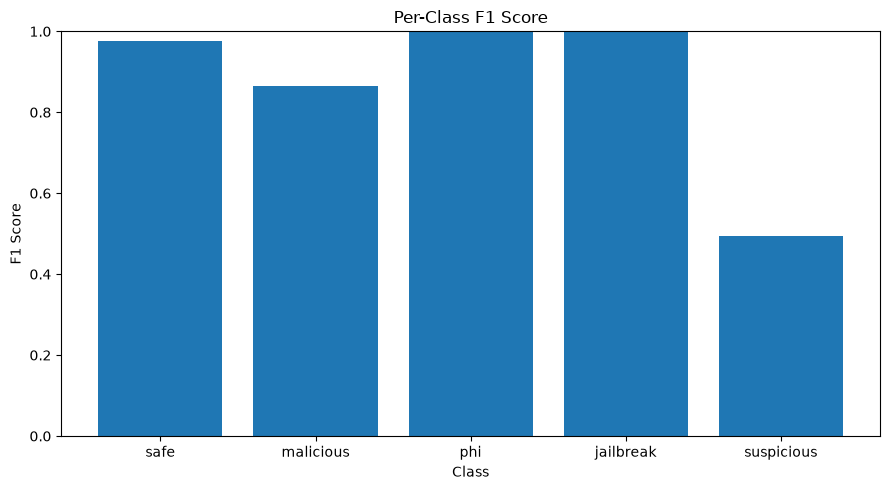

Saved: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\evaluation\per_class_f1.png


In [203]:
# ============================================================
# PER-CLASS F1
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    class_names,
    per_class_metrics["F1"]
)

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Score")
plt.ylim(0, 1)

plt.tight_layout()

path = OUTPUT_DIR / "per_class_f1.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

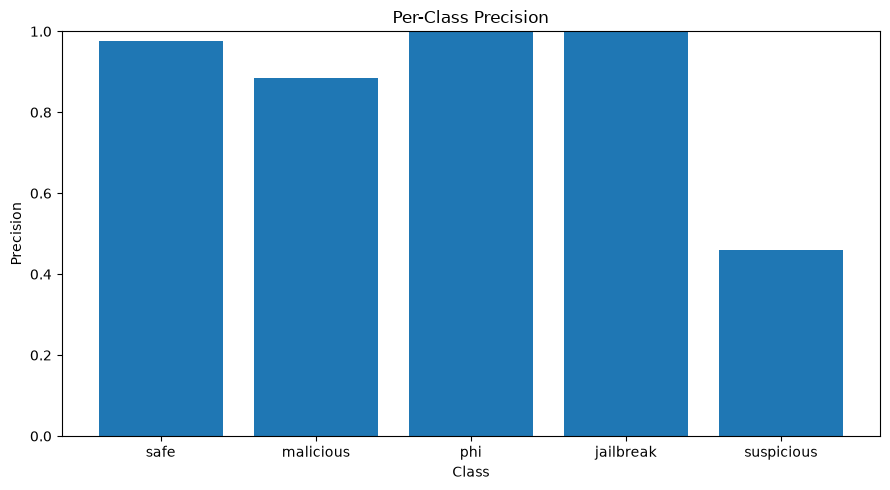

Saved: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\evaluation\per_class_precision.png


In [204]:
# ============================================================
# PER-CLASS PRECISION
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    class_names,
    per_class_metrics["Precision"]
)

plt.xlabel("Class")
plt.ylabel("Precision")
plt.title("Per-Class Precision")
plt.ylim(0, 1)

plt.tight_layout()

path = OUTPUT_DIR / "per_class_precision.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

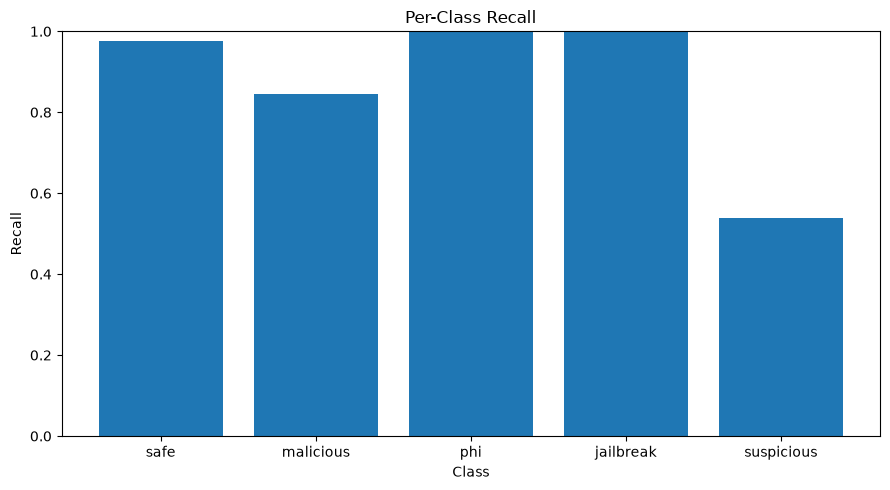

Saved: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\evaluation\per_class_recall.png


In [205]:
# ============================================================
# PER-CLASS RECALL
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    class_names,
    per_class_metrics["Recall"]
)

plt.xlabel("Class")
plt.ylabel("Recall")
plt.title("Per-Class Recall")
plt.ylim(0, 1)

plt.tight_layout()

path = OUTPUT_DIR / "per_class_recall.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

In [206]:
# ============================================================
# SAVE TEST METRICS
# ============================================================

metrics_path = OUTPUT_DIR / "test_metrics.txt"

with open(metrics_path, "w", encoding="utf-8") as f:

    f.write("SECURITY CLASSIFIER TEST SET EVALUATION\n")
    f.write("=" * 50 + "\n\n")

    f.write(f"Test samples: {len(test_df)}\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Macro Precision: {macro_precision:.4f}\n")
    f.write(f"Macro Recall: {macro_recall:.4f}\n")
    f.write(f"Macro F1: {macro_f1:.4f}\n")
    f.write(f"Weighted F1: {weighted_f1:.4f}\n\n")

    f.write("Per-Class Metrics\n")
    f.write("-" * 50 + "\n")

    for class_name in class_names:

        precision = report_df.loc[
            class_name, "precision"
        ]

        recall = report_df.loc[
            class_name, "recall"
        ]

        f1 = report_df.loc[
            class_name, "f1-score"
        ]

        f.write(
            f"{class_name}: "
            f"Precision={precision:.4f}, "
            f"Recall={recall:.4f}, "
            f"F1={f1:.4f}\n"
        )

print("Saved:", metrics_path)

Saved: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\evaluation\test_metrics.txt


In [207]:
# ============================================================
# MISCLASSIFIED SAMPLES
# ============================================================

misclassified_mask = true_ids != pred_ids

misclassified_df = test_df.loc[
    misclassified_mask
].copy()

misclassified_df["actual_label"] = [
    id2label[int(idx)]
    for idx in true_ids[misclassified_mask]
]

misclassified_df["predicted_label"] = [
    id2label[int(idx)]
    for idx in pred_ids[misclassified_mask]
]

misclassified_df["prediction_confidence"] = (
    pred_probs[misclassified_mask].max(axis=1)
)

print(
    "Total misclassified samples:",
    len(misclassified_df)
)

display(
    misclassified_df[
        [
            TEXT_COLUMN,
            "actual_label",
            "predicted_label",
            "prediction_confidence"
        ]
    ].head(20)
)

Total misclassified samples: 141


,prompt,actual_label,predicted_label,prediction_confidence
3,Three days after admission to the hospital wit...,safe,malicious,0.460560
15,A 33-year-old individual with HIV presents for...,malicious,suspicious,0.928721
22,A 24-year-old woman comes to the emergency dep...,suspicious,malicious,0.929405
60,A 32-year-old man presents with a history of d...,suspicious,safe,0.725987
89,A 69-year-old man presents to his primary care...,malicious,suspicious,0.521854
99,A 24-year-old man presents to the physician be...,suspicious,malicious,0.927406
106,A 22-year-old primigravid woman comes to the p...,malicious,safe,0.758385
112,A 24-year-old woman presents with a 3-month hi...,safe,suspicious,0.897934
133,Based on current clinical evidence and guideli...,suspicious,malicious,0.812058
138,A 72-year-old patient is referred to an ophtha...,malicious,suspicious,0.906034


In [208]:
# ============================================================
# SAVE MISCLASSIFIED SAMPLES
# ============================================================

misclassified_path = (
    OUTPUT_DIR / "misclassified_samples.csv"
)

misclassified_df.to_csv(
    misclassified_path,
    index=False
)

print("Saved:", misclassified_path)

Saved: C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\outputs\evaluation\misclassified_samples.csv


In [209]:
# ============================================================
# CONFUSION PAIRS
# ============================================================

confusion_pairs = (
    misclassified_df
    .groupby(
        ["actual_label", "predicted_label"]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

display(confusion_pairs)

,actual_label,predicted_label,count
1,malicious,suspicious,42
5,suspicious,safe,23
2,safe,malicious,22
4,suspicious,malicious,20
0,malicious,safe,17
3,safe,suspicious,17


In [210]:
# ============================================================
# FINAL PHASE 5 ARTIFACT CHECK
# ============================================================

required_files = [
    "classification_report.csv",
    "confusion_matrix.png",
    "per_class_f1.png",
    "per_class_precision.png",
    "per_class_recall.png",
    "test_metrics.txt",
    "misclassified_samples.csv"
]

print("PHASE 5 OUTPUT CHECK")
print("=" * 50)

all_exist = True

for filename in required_files:

    path = OUTPUT_DIR / filename

    if path.exists():
        print(f"✓ {filename}")
    else:
        print(f"✗ {filename}")
        all_exist = False

print()

if all_exist:
    print("PHASE 5 EVALUATION COMPLETE")
else:
    print("Some files are missing.")

PHASE 5 OUTPUT CHECK
✓ classification_report.csv
✓ confusion_matrix.png
✓ per_class_f1.png
✓ per_class_precision.png
✓ per_class_recall.png
✓ test_metrics.txt
✓ misclassified_samples.csv

PHASE 5 EVALUATION COMPLETE
